## Tarea 2: Redes Neuronales



Instrucciones: 
1. Ponle de nombre a tu tarea `tarea_1.ipynb` un Jupyter Notebook (5 points) 
2. Escribe tu nombre comleto y tus iniciales en tu notebook después de la siguiente nota: 
*Este trabajo es mio y sigue la integridad académica del Tec. de Monterrey*
3. Agrega los nombres de todos los compañeros con los que trabajaste. Recuerda que puedes discutir con tus compañeros pero cada quien tiene que entregar su tarea.
4. **ADVERTENCIA!** no se permite el uso de LLMs para estas tareas! El aprendizaje profundo no va a hacer la tarea de aprendizaje profundo... Si no entienden bien los conceptos no hay diferencia entre ustedes y el LLM y esto es sad, se mueren las hadas cuando hacen esto :(
5. Asegurate que tu código corra!
6. Las preguntas de teoria contestalas en texto usando markdown, no comentarios en python

1. Dada está red neuronal superficial: $y = \phi_0 + \phi_1 a(\theta_{10} + \theta_{11}x) + \phi_2 a(\theta_{20} + \theta_{21}x) + \phi_3 a(\theta_{30} + \theta_{31}x)$.

     a. ¿Qué clase de mapeo de x a y se va a crear si la función de activación es lineal $a(z) = \phi_0 +\phi_1 z$? Inlcuye una gráfica de como se vería esto para una función en particular (fijando los parámtros).
     
     b. ¿Qué clase de mapeo de x a y se va a crear si la función de activación es la identidad $a(z) = z$? Inlcuye una gráfica de como se vería esto para una función en particular (fijando los parámtros).

2. Prueba la siguiente propiedad que es se cumple para $\alpha \in \mathbb{R}^+$. Esta propiedad se conoce como homegeneidad no-negativa

$$ReLU(\alpha z) = \alpha ReLU(z)$$

3. Dada la siguiente red neuronal: 
$$y = \phi_0 + \phi_1 h_1 + \phi_2 h_2 + \phi_3 h_3$$
donde: 
   $$h_1 = a(\theta_{10} + \theta_{11}x) \quad \quad h_2 = a(\theta_{20} + \theta_{21}x) \quad \quad h_3 = a(\theta_{30} + \theta_{31}x)$$
a. ¿Qué pasa si a una red neuronal superficial definida acá abajo si multiplicamos los parámetros $\theta_{10}$ y $\theta_{11}$ por una constante positiva $\alpha$ y dividimos $\phi_1$ por ese mismo $\alpha$? 

b. ¿Qué pasa si $\alpha < 1$?

4. Considera una red neruonal con los siguientes paráametros: 

$\{\phi_0, \phi_1, \phi_2, \phi_3, \theta_{10},\theta_{11}, \theta_{20}, \theta_{21}, \theta_{30}, \theta_{31} \} = \{−0.23, −1.3, 1.3, 0.66, −0.2, 0.4, −0.9, 0.9, 1.1, −0.7\}$

Recrea las siguientes gráficas cambiando la función de activación por las siguientes: 

1. $heaviside(z) = \begin{cases}
         0 & z < 0\\
         1 & z \geq 0
        \end{cases} $
2. $tanh(z)$ 
3.  $rect(z) = \begin{cases}
         0 & z < 0\\
         1 & 0 \leq z \leq 1\\
         0 & z > 1
        \end{cases} $

¿Qué encuentras de este análisis?

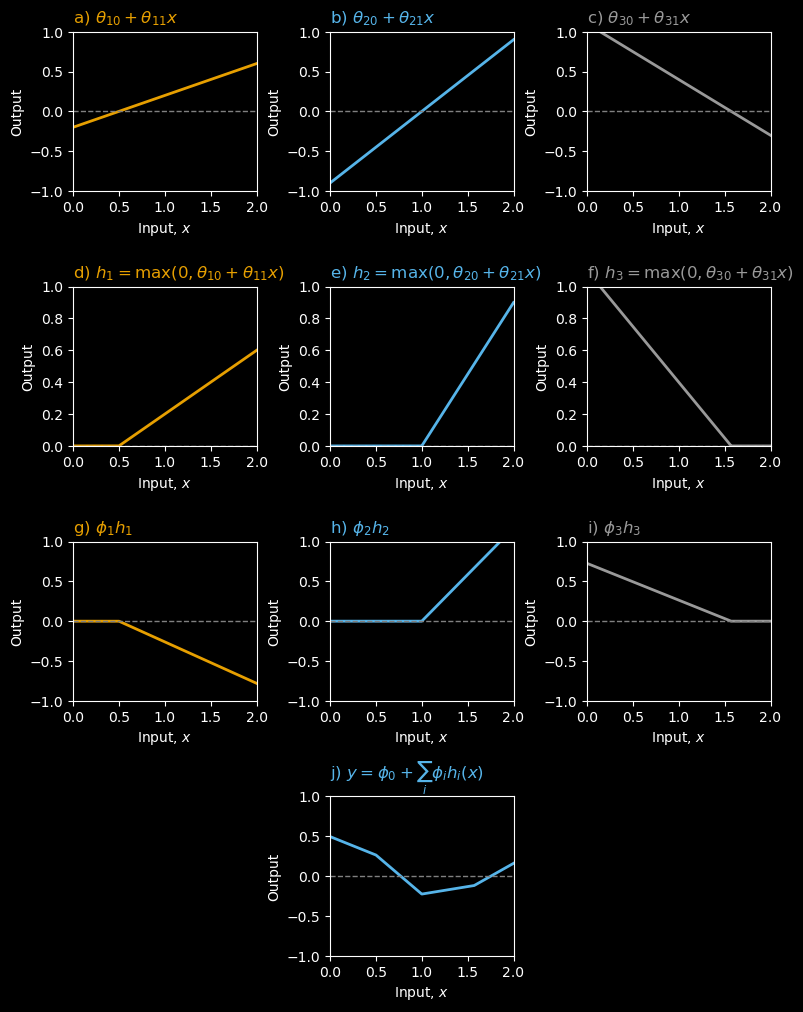

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 1. Definimos los parámetros 
phi0, phi1, phi2, phi3 = -0.23, -1.3, 1.3, 0.66
theta10, theta11 = -0.2,  0.4
theta20, theta21 = -0.9,  0.9
theta30, theta31 =  1.1, -0.7
x = np.linspace(0, 2, 500)

# 2. Calculamos cada unidad oculta antes de activación: l_i(x) = θ_i0 + θ_i1 * x
l1 = theta10 + theta11 * x
l2 = theta20 + theta21 * x
l3 = theta30 + theta31 * x

# 3. Calculamos la función de activación: h_i(x) = max(0, ℓ_i(x))
h1 = np.maximum(0, l1)
h2 = np.maximum(0, l2)
h3 = np.maximum(0, l3)

# 4. Ponderamos las activaciones: φ_i * h_i(x)
w1 = phi1 * h1
w2 = phi2 * h2
w3 = phi3 * h3

# 5. Resultado de la red: y(x) = φ₀ + Σ φ_i h_i(x)
y = phi0 + w1 + w2 + w3

# 6) Graficamos: 
plt.style.use('dark_background')
fig = plt.figure(figsize=(9, 12))
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.6, wspace=0.4)
def zero_line(ax):
    ax.axhline(0, color='grey', linestyle='--', linewidth=1)
for i, (ℓ, col, title) in enumerate(zip(
    [l1, l2, l3],
    ["#E69F00", "#56B4E9", "#999999"],
    ["a) $\\theta_{10}+\\theta_{11}x$",
     "b) $\\theta_{20}+\\theta_{21}x$",
     "c) $\\theta_{30}+\\theta_{31}x$"]
  )):
    ax = fig.add_subplot(gs[0, i])
    ax.plot(x, ℓ, color=col, linewidth=2)
    zero_line(ax)
    ax.set_xlim(0,2); ax.set_ylim(-1,1)
    ax.set_title(title, loc='left', color=col, fontsize=12)
    ax.set_ylabel("Output")
    ax.set_xlabel("Input, $x$")
    ax.grid(False)
for i, (h, col, title) in enumerate(zip(
    [h1, h2, h3],
    ["#E69F00", "#56B4E9", "#999999"],
    ["d) $h_1=\\max(0,\\theta_{10}+\\theta_{11}x)$",
     "e) $h_2=\\max(0,\\theta_{20}+\\theta_{21}x)$",
     "f) $h_3=\\max(0,\\theta_{30}+\\theta_{31}x)$"]
  )):
    ax = fig.add_subplot(gs[1, i])
    ax.plot(x, h, color=col, linewidth=2)
    zero_line(ax)
    ax.set_xlim(0,2); ax.set_ylim(0,1)
    ax.set_title(title, loc='left', color=col, fontsize=12)
    ax.set_ylabel("Output")
    ax.set_xlabel("Input, $x$")
    ax.grid(False)
for i, (w, col, title) in enumerate(zip(
    [w1, w2, w3],
    ["#E69F00", "#56B4E9", "#999999"],
    ["g) $\\phi_1 h_1$",
     "h) $\\phi_2 h_2$",
     "i) $\\phi_3 h_3$"]
  )):
    ax = fig.add_subplot(gs[2, i])
    ax.plot(x, w, color=col, linewidth=2)
    zero_line(ax)
    ax.set_xlim(0,2); ax.set_ylim(-1,1)
    ax.set_title(title, loc='left', color=col, fontsize=12)
    ax.set_ylabel("Output")
    ax.set_xlabel("Input, $x$")
    ax.grid(False)
ax = fig.add_subplot(gs[3, 1])
ax.plot(x, y, color="#56B4E9", linewidth=2)
zero_line(ax)
ax.set_xlim(0,2); ax.set_ylim(-1,1)
ax.set_title("j) $y = \\phi_0 + \\sum_i \\phi_i h_i(x)$", loc='left', color="#56B4E9", fontsize=12)
ax.set_ylabel("Output")
ax.set_xlabel("Input, $x$")
ax.grid(False)

plt.show()

5. Consideremos una red neuronal superficial con 1 input, 1 output y 3 unidades ocultas. Sabemos por las notas de clases que esta red va a crear cuatro regiones lineales. ¿Qué se necesita cumplir para que esta red genere menos de cuatro regiones lineales?

6. Para las siguientes redes, calcula cuantos parámetros tiene cada una: 
     a. Red con 1 input, 4 unidades ocultas y 2 outputs 
     b. Red con 2 inputs, 5 unidades ocultas y 3 outputs  

7. Encuentra una expresión general para el número de parámetros de una red con inputs con dimensiones $D_i$, outputs con dimensiones $D_o$ y $D$ unidades ocultas. 

8. Vamos a construir una red neuronal desde 0 en python (gran parte de este código esta arriba) 

     a. Define la función de activación ReLU (tiene que ser una función en python)

     b. Define una red neuronal con 1 input, 1 output y 3 unidades ocultas (tiene que ser una función en python)

     c. Define una función que grafica tu red neuronal, asume que el rango del input es $[0,1]$ y que el rango del output es $[-1,1]$ (tiene que ser una función que recibe input, output, las pre activaciones, las activaciones y los pesos de cada activación). 

     d. Prueba tu código usando los siguientes parámetros: $\theta_{10} = 0.3$, $\theta_{11} = -1.0$, $\theta_{20} = -1.0$, $\theta_{21} = 2.0$, $\theta_{30} = -0.5$, $\theta_{31} = 0.65$, $\phi_0 = -0.3$, $\phi_1 = 2.0$, $\phi_2 = -1.0$, $\phi_3 = 7.0$


9. Usando el código que creaste y los parámetros para tu red vamos a evaluar lo siguiente. Para estas preguntas contesta con una oración o dos teoricamente que pasa ademas de correr tu código para ver graficamente que esta pasando con la red. 
    
    a. ¿Qué efecto tiene en la red cambiar $\phi_0$?

    b. ¿Qué efecto tiene multiplicar $phi_1, phi_2, phi_3$ por 0.5?

    c. ¿Qué efecto tiene multiplicar $phi_1$ por -1?

    d. Encuentra un conjunto de parámetros de tal manera que solo haya dos articulaciones en tu red (incluyendo el rango fuera de la gráfica). Existen tres maneras de hacer esto, encuentra al menos 1

    e. Con los parámetros originales el segundo segmento es una linea recta sin pendiente. ¿Cómo cambiarias $\theta_{10}$ para que ningun segmento tenga pendiente cero?

10. Considera la función de pérdida cuadrática: 

$$L(\phi) = \sum_{i=1}^I(y_i - f(x_i,\phi))^2$$

a. Escribe esta función de pérdida en python 

b. Usando los mismos parámetros que en las dos preguntas anteriores y los datos de entrenamiento de acá abajo: corre tu red en los datos de entrenamiento 

c. Calcula que tan bien o mal lo está haciendo está red 

d. Juega un poco con los parámetros e intenta reducir la función de pérdida. ¿Qué parametro parece más útil para hacer esto? 

In [3]:
x_train = np.array([0.09291784,0.46809093,0.93089486,0.67612654,0.73441752,0.86847339,\
                   0.49873225,0.51083168,0.18343972,0.99380898,0.27840809,0.38028817,\
                   0.12055708,0.56715537,0.92005746,0.77072270,0.85278176,0.05315950,\
                   0.87168699,0.58858043])
y_train = np.array([-0.15934537,0.18195445,0.451270150,0.13921448,0.09366691,0.30567674,\
                    0.372291170,0.40716968,-0.08131792,0.41187806,0.36943738,0.3994327,\
                    0.019062570,0.35820410,0.452564960,-0.0183121,0.02957665,-0.24354444, \
                    0.148038840,0.26824970])

11. ¿Cuántos y cuáles son los hiperparámetros de la siguiente red?

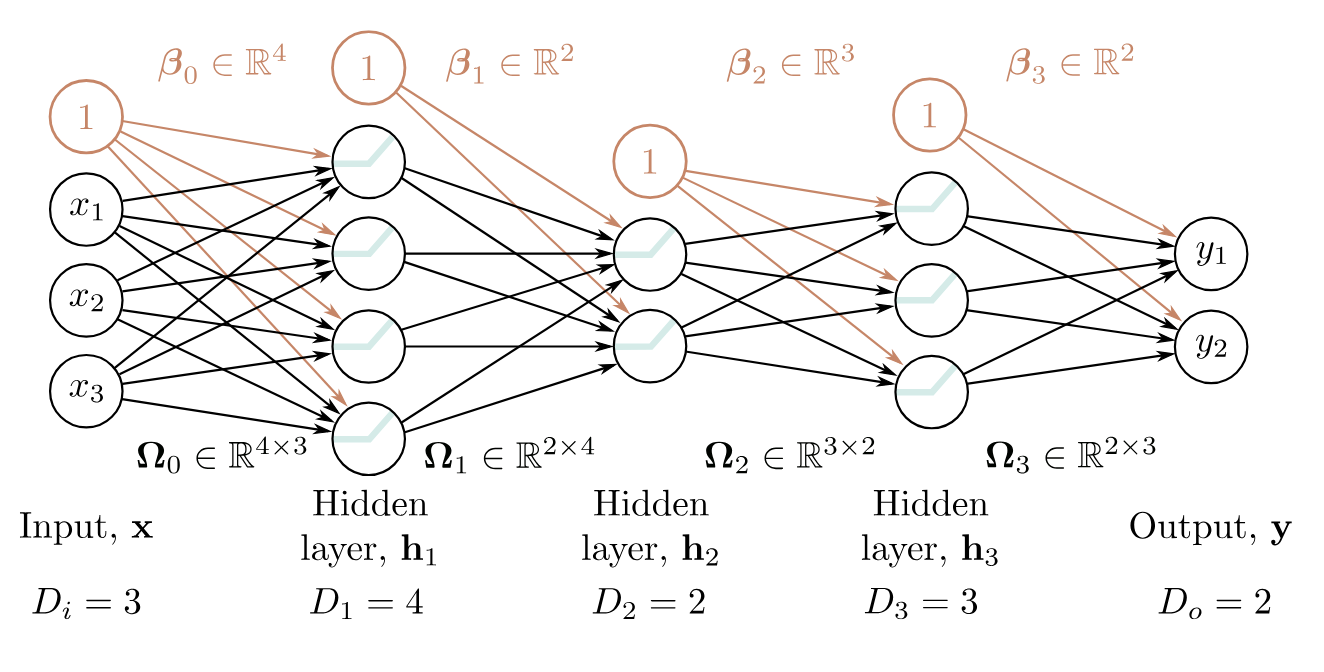

In [1]:
from IPython.display import Image, display
display(Image(filename="../Imagenes/red_profunda_e1.png"))

12. Considera una red neuronal profunda con un solo input, un solo output, K capas ocultas y D neuronas por capa. Prueba que la red va a tener $3D + 1 + (K − 1)D(D + 1)$ parámetros. 